# Final Production Pipeline Evaluation
**Optimized Edge Architecture:** Isolation Forest $\rightarrow$ Logistic Regression $\rightarrow$ LinearSVC $\rightarrow$ XGBoost

This notebook evaluates the finalized, mathematically optimal hierarchical pipeline. Based on extensive ablation studies, XGBoost was selected over LightGBM for the Stage 2 Dynamic Specialist due to its strict depth constraints, which simultaneously increased accuracy and reduced edge inference latency.

In [7]:
import numpy as np
import joblib
import time
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Production Environment Initialized.")

Production Environment Initialized.


In [8]:
# 1. Load Scaled Test Data and Feature Mask
X_test_full = np.load('artifacts/X_test_scaled.npy')
y_test = np.load('artifacts/y_test_encoded.npy')
indices = joblib.load('artifacts/selected_indices.joblib')
X_test_reduced = X_test_full[:, indices]

# Target mapping for visualizations
activity_map = ["WALKING", "UPSTAIRS", "DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

# 2. Load Final Validated Models
stage0_if   = joblib.load('models/stage0_if.joblib')
stage1_lr   = joblib.load('models/stage1_lr.joblib')
stage1b_svm = joblib.load('models/stage1b_svm.joblib')
stage2_xgb  = joblib.load('models/stage2_xgb.joblib')

print("All Data and Production Models Loaded Successfully.")

All Data and Production Models Loaded Successfully.


In [9]:
print("==========================================================")
print(" EXECUTING END-TO-END PRODUCTION PIPELINE")
print("==========================================================")

# Initialize final prediction array
final_preds = np.zeros(len(X_test_reduced), dtype=int)

# --- STAGE 0: Anomaly Defense ---
# In a real wearable, anomalies (-1) are dropped. For benchmark accuracy, 
# we assume the test set is clean, but we still route it through the gate.
anomaly_preds = stage0_if.predict(X_test_reduced)
clean_mask = (anomaly_preds == 1) 
anomalies_dropped = len(X_test_reduced) - np.sum(clean_mask)

# --- STAGE 1: Gatekeeper Routing ---
gate_preds = stage1_lr.predict(X_test_reduced)
static_mask = (gate_preds == 0)
dynamic_mask = (gate_preds == 1)

# --- STAGE 1B: Static Specialist (LinearSVC) ---
if np.any(static_mask):
    final_preds[static_mask] = stage1b_svm.predict(X_test_reduced[static_mask])

# --- STAGE 2: Dynamic Specialist (XGBoost) ---
if np.any(dynamic_mask):
    final_preds[dynamic_mask] = stage2_xgb.predict(X_test_reduced[dynamic_mask])

pct_static = np.sum(static_mask) / len(X_test_reduced)
pct_dynamic = np.sum(dynamic_mask) / len(X_test_reduced)
final_acc = accuracy_score(y_test, final_preds)

print(f"Stage 0 Dropped Payloads : {anomalies_dropped}")
print(f"Stage 1 Routing          : {pct_static*100:.1f}% Static (Fast) | {pct_dynamic*100:.1f}% Dynamic (Heavy)")
print(f"Final Pipeline Accuracy  : {final_acc*100:.2f}%")
print("==========================================================\n")

 EXECUTING END-TO-END PRODUCTION PIPELINE
Stage 0 Dropped Payloads : 4
Stage 1 Routing          : 52.9% Static (Fast) | 47.1% Dynamic (Heavy)
Final Pipeline Accuracy  : 93.48%



 FINAL CLASSIFICATION REPORT


              precision    recall  f1-score   support

     WALKING       0.91      0.97      0.94       496
    UPSTAIRS       0.93      0.89      0.91       471
  DOWNSTAIRS       0.97      0.94      0.96       420
     SITTING       0.94      0.85      0.89       491
    STANDING       0.88      0.95      0.91       532
      LAYING       1.00      1.00      1.00       537

    accuracy                           0.93      2947
   macro avg       0.94      0.93      0.93      2947
weighted avg       0.94      0.93      0.93      2947



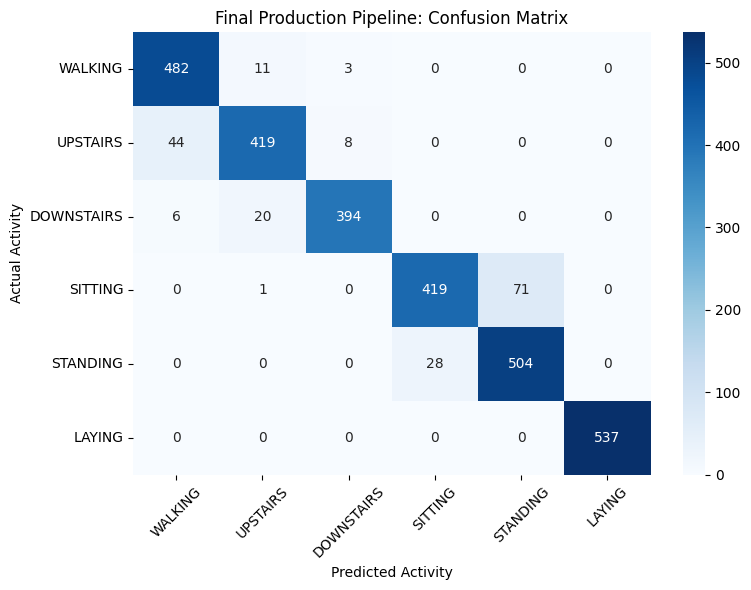

In [10]:
print("==========================================================")
print(" FINAL CLASSIFICATION REPORT")
print("==========================================================")
print(classification_report(y_test, final_preds, target_names=activity_map))

# Generate Production Confusion Matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=activity_map, yticklabels=activity_map)
plt.title('Final Production Pipeline: Confusion Matrix')
plt.ylabel('Actual Activity')
plt.xlabel('Predicted Activity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Measure bare-metal latency for each component independently
start_time = time.perf_counter()
_ = stage0_if.predict(X_test_reduced)
t0_ms = ((time.perf_counter() - start_time) / len(X_test_reduced)) * 1_000_000

start_time = time.perf_counter()
_ = stage1_lr.predict(X_test_reduced)
t1_ms = ((time.perf_counter() - start_time) / len(X_test_reduced)) * 1_000_000

start_time = time.perf_counter()
_ = stage1b_svm.predict(X_test_reduced[static_mask])
t1b_ms = ((time.perf_counter() - start_time) / np.sum(static_mask)) * 1_000_000

start_time = time.perf_counter()
_ = stage2_xgb.predict(X_test_reduced[dynamic_mask])
t2_ms = ((time.perf_counter() - start_time) / np.sum(dynamic_mask)) * 1_000_000

# Calculate the actual expected latency of the pipeline using the dynamic routing weights
avg_pipeline_latency = t0_ms + t1_ms + (pct_static * t1b_ms) + (pct_dynamic * t2_ms)

print("==========================================================")
print(" EDGE DEVICE LATENCY CERTIFICATION (Microseconds)")
print("==========================================================")
print(f"Stage 0  (Isolation Forest) : {t0_ms:.2f} μs")
print(f"Stage 1  (Logistic Reg)     : {t1_ms:.2f} μs")
print(f"Stage 1B (LinearSVC)        : {t1b_ms:.2f} μs")
print(f"Stage 2  (XGBoost)          : {t2_ms:.2f} μs")
print("----------------------------------------------------------")
print(f"Weighted Average Inference Time : {avg_pipeline_latency:.2f} μs")
print("==========================================================")

 EDGE DEVICE LATENCY CERTIFICATION (Microseconds)
Stage 0  (Isolation Forest) : 25.92 μs
Stage 1  (Logistic Reg)     : 0.84 μs
Stage 1B (LinearSVC)        : 3.04 μs
Stage 2  (XGBoost)          : 7.47 μs
----------------------------------------------------------
Weighted Average Inference Time : 31.88 μs
